# Variables qualitatives et quantitatives

## Modules importés

In [3]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## Connection BDD

In [4]:
def getBDD():
    try:
        return mysql.connector.connect(
            host='localhost', database='gamesale',
            user='root', password='', charset='utf8'
        )
    except Exception as e:
        print(f"Connection Error: {e}")
        return None

## Relations entre les tables

In [5]:
RELATIONSHIPS = {
    'genre': "JOIN genre ON jeux.id_jeu = genre.id_jeu",
    'editeur': "JOIN editeur ON jeux.id_jeu = editeur.id_jeu",
    'developpeur': "JOIN developpeur ON jeux.id_jeu = developpeur.id_jeu",
    'os': "JOIN a_os ON jeux.id_jeu = a_os.id_jeu JOIN os ON a_os.id_os = os.id_os",
    'categorie': "JOIN a_categorie ON jeux.id_jeu = a_categorie.id_jeu JOIN categorie ON a_categorie.id_cat = categorie.id_cat"
}

## Fonction pour les années et une variable quantitative

In [ ]:
def plot_boxplot_annee(numeric_col, label_x="Année", label_y="Valeur"):
    connect = getBDD()
    if not connect: return

    sql = f"SELECT annee, {numeric_col} FROM jeux"
    df = pd.read_sql(sql, connect)
    connect.close()

    df[numeric_col] = df[numeric_col].astype(str).str.replace(',', '.')
    df[numeric_col] = pd.to_numeric(df[numeric_col], errors='coerce')
    
    df['annee'] = df['annee'].astype(str).str.strip()
    df = df[df['annee'] != '']
    df = df[df['annee'].str.lower() != 'nan']
    df = df.dropna(subset=[numeric_col, 'annee'])

    df['annee'] = pd.to_numeric(df['annee']).astype(int)

    upper_limit = df[numeric_col].quantile(0.90)
    df = df[df[numeric_col] <= upper_limit]

    counts = df['annee'].value_counts()
    valid_years = counts[counts >= 7].index
    df = df[df['annee'].isin(valid_years)]
    year_order = sorted(df['annee'].unique())

    plt.figure(figsize=(15, 7))
    
    sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)
    plt.title(f'Distribution de {numeric_col} par Année (Top 10% outliers supprimés)', fontsize=15)
    plt.xlabel(label_x, fontsize=12)
    plt.ylabel(label_y, fontsize=12)
    
    plt.xticks(rotation=45)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Année et Ventes globales

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


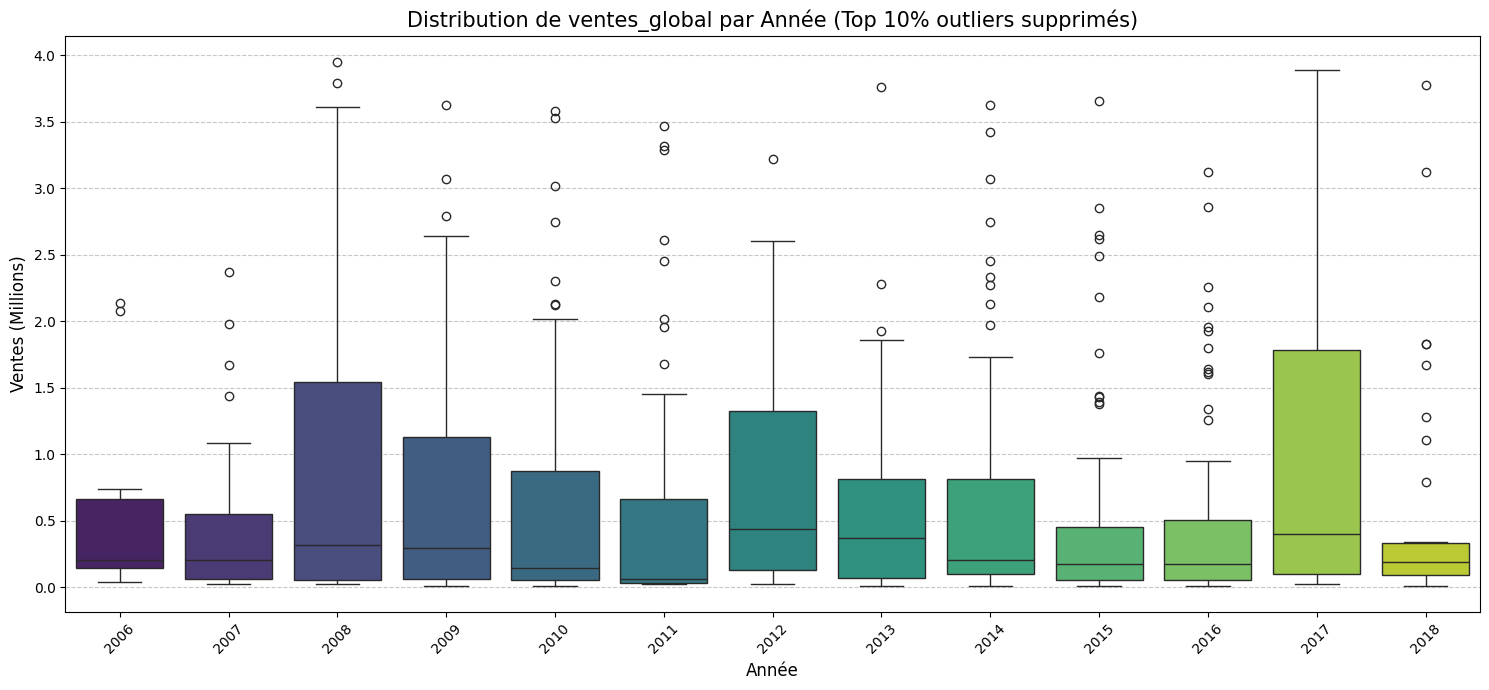

In [26]:
plot_boxplot_annee('ventes_global', "Année", "Ventes (Millions)")

## Année et Ventes en Amérique du Nord

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


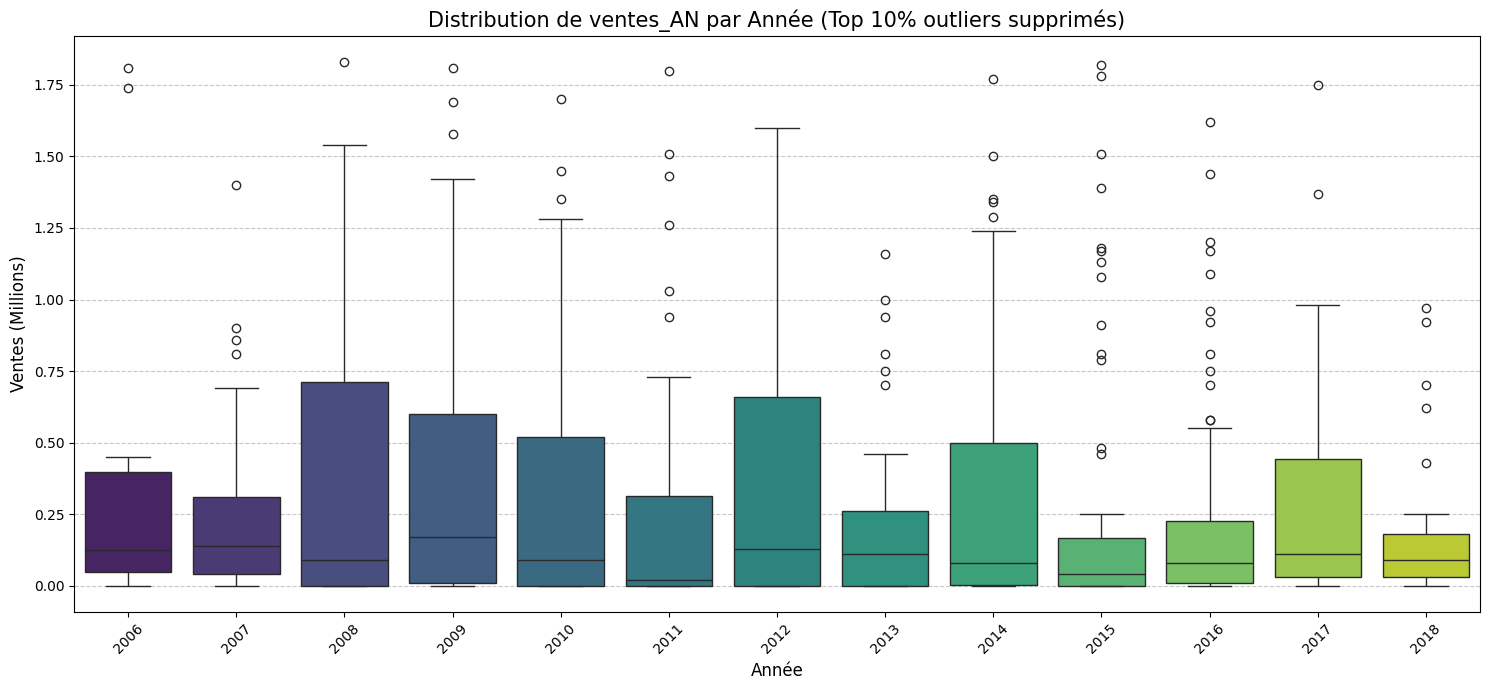

In [30]:
plot_boxplot_annee('ventes_AN', "Année", "Ventes (Millions)")

## Année et Ventes en Europe

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


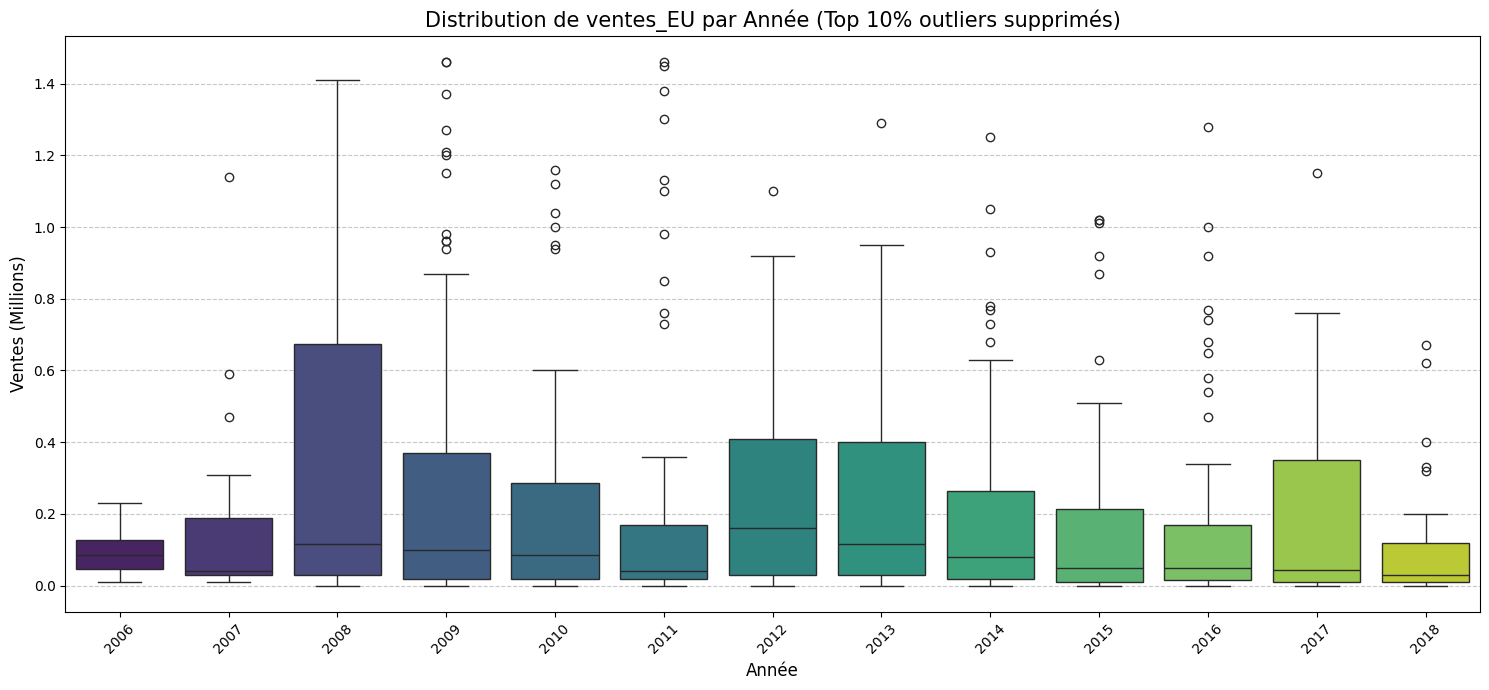

In [29]:
plot_boxplot_annee('ventes_EU', "Année", "Ventes (Millions)")

## Année et Ventes au Japon

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


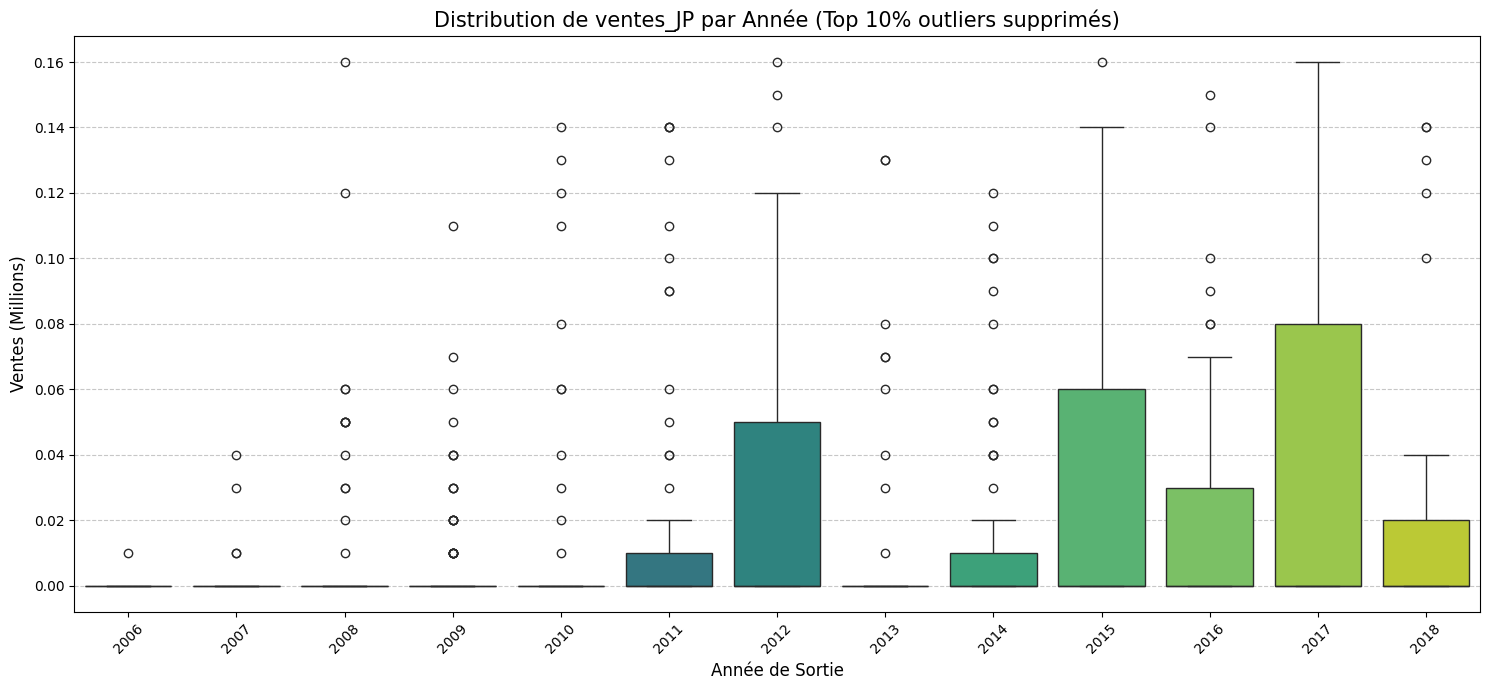

In [31]:
plot_boxplot_annee('ventes_JP', "Année de Sortie", "Ventes (Millions)")

## Année et Autres Ventes

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


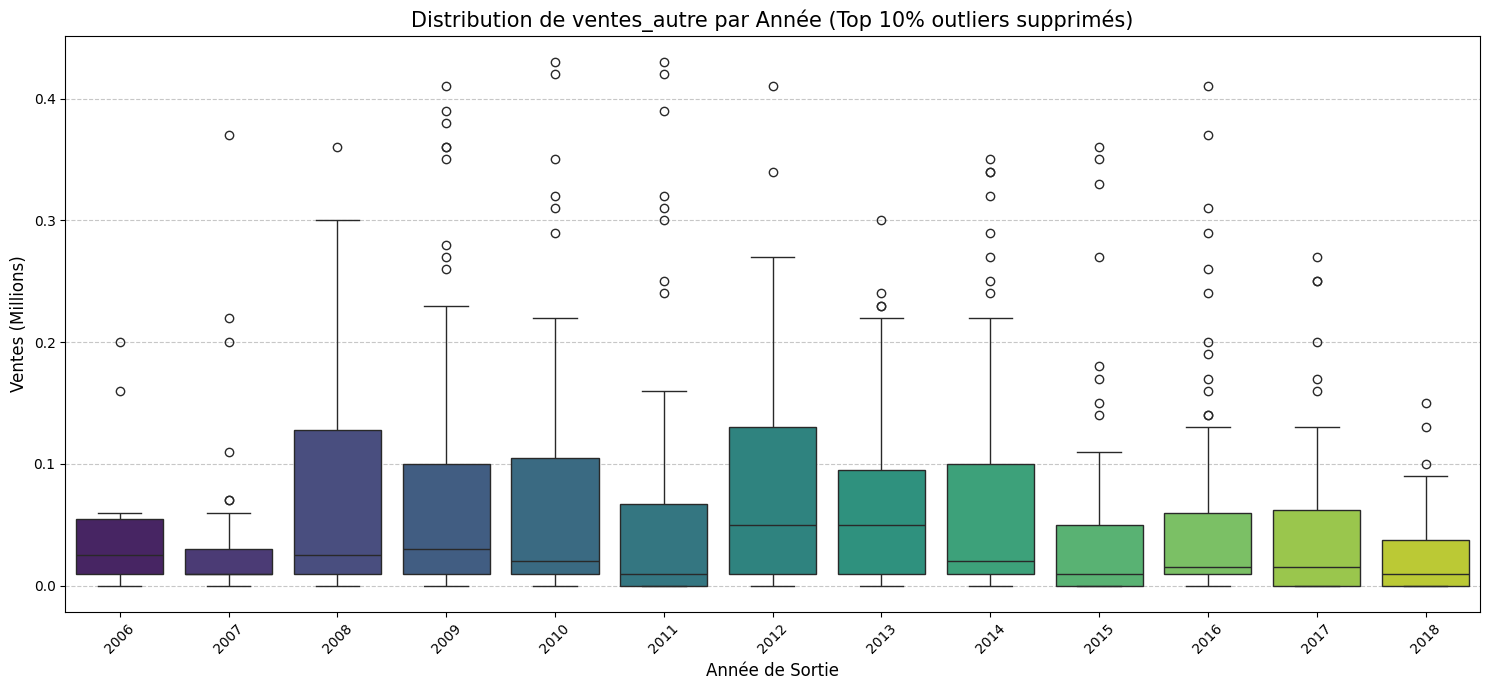

In [32]:
plot_boxplot_annee('ventes_autre', "Année de Sortie", "Ventes (Millions)")

## Année et Prix

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3376713389.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


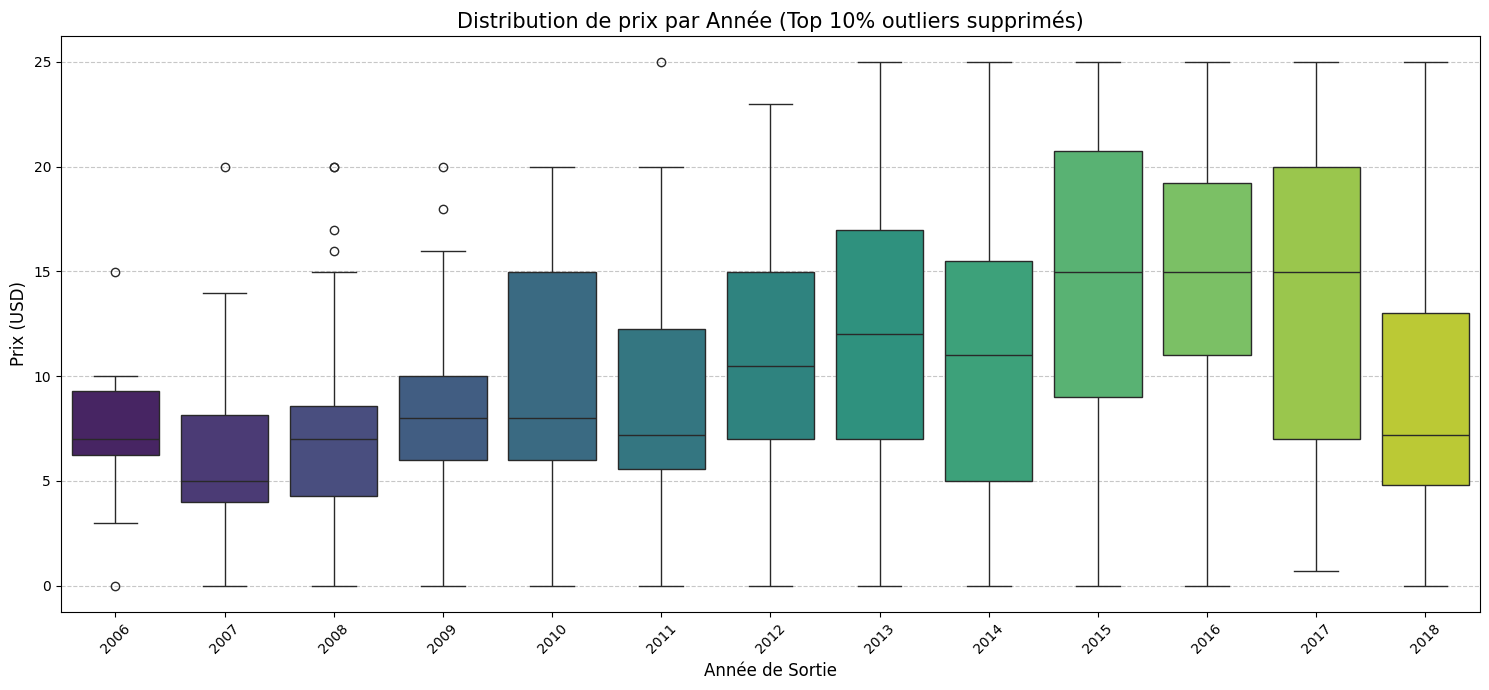

In [33]:
plot_boxplot_annee('prix', "Année de Sortie", "Prix (USD)")

## Fonction pour les genres et une variable quantitative

In [38]:
def plot_boxplot_genres(numeric_col, label_x="Genre", label_y="Valeur"):
    connect = getBDD()
    if not connect: return

    sql = f"""
        SELECT genre.genre, jeux.{numeric_col} 
        FROM jeux 
        JOIN genre ON jeux.id_jeu = genre.id_jeu
    """
    
    df = pd.read_sql(sql, connect)
    connect.close()

    df[numeric_col] = df[numeric_col].astype(str).str.replace(',', '.')
    df[numeric_col] = pd.to_numeric(df[numeric_col], errors='coerce')

    df['genre'] = df['genre'].astype(str).str.strip()
    df = df[df['genre'] != '']
    df = df[df['genre'].str.lower() != 'nan']
    
    df = df.dropna(subset=[numeric_col, 'genre'])

    upper_limit = df[numeric_col].quantile(0.90)
    df = df[df[numeric_col] <= upper_limit]

    counts = df['genre'].value_counts()
    valid_genres = counts[counts >= 7].index
    df = df[df['genre'].isin(valid_genres)]
    
    order = df.groupby('genre')[numeric_col].median().sort_values(ascending=False).index

    plt.figure(figsize=(14, 8))
    
    sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')

    plt.title(f'Distribution de {numeric_col} par Genre (Top 10% outliers supprimés)', fontsize=15)
    plt.xlabel(label_x, fontsize=12, fontweight='bold')
    plt.ylabel(label_y, fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Genres et Ventes globales

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


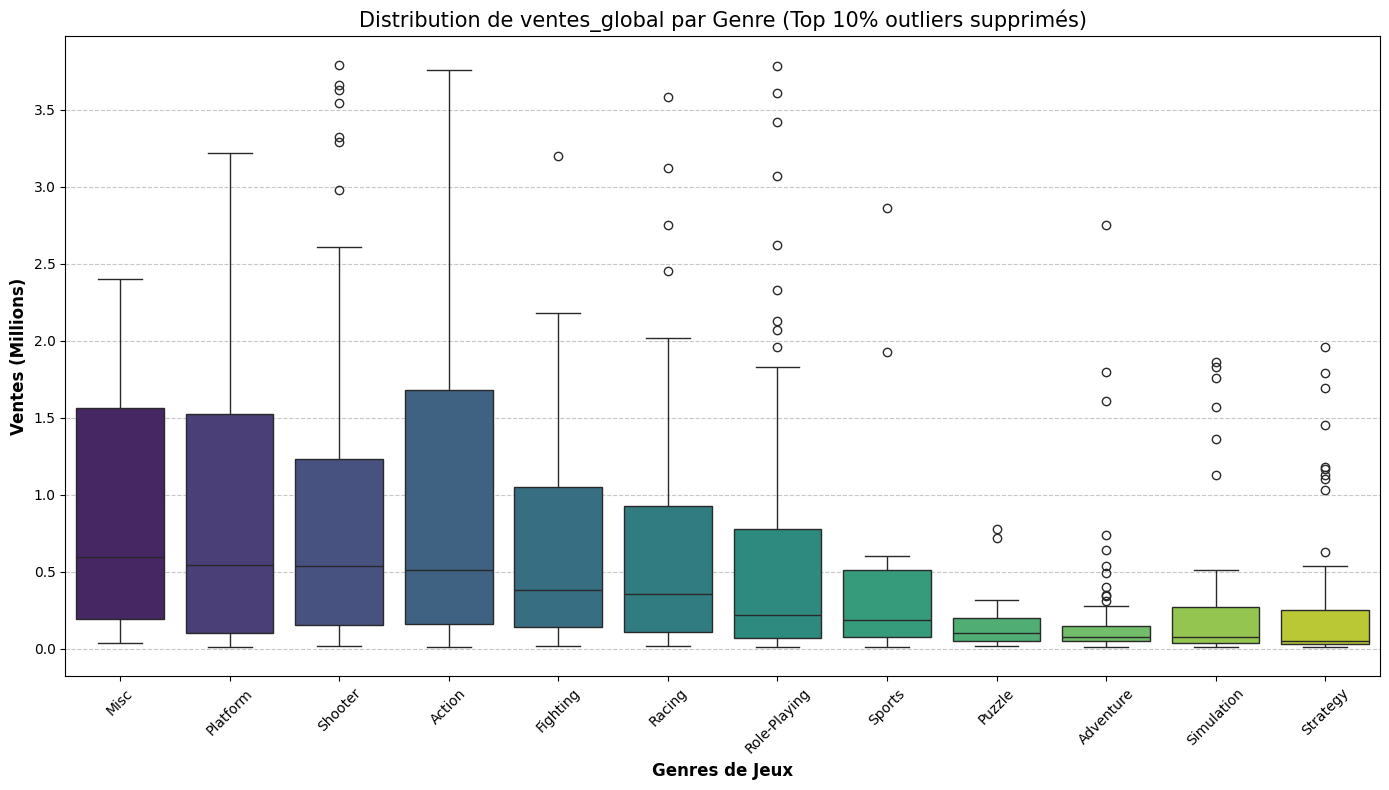

In [39]:
plot_boxplot_genres('ventes_global', "Genres de Jeux", "Ventes (Millions)")

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


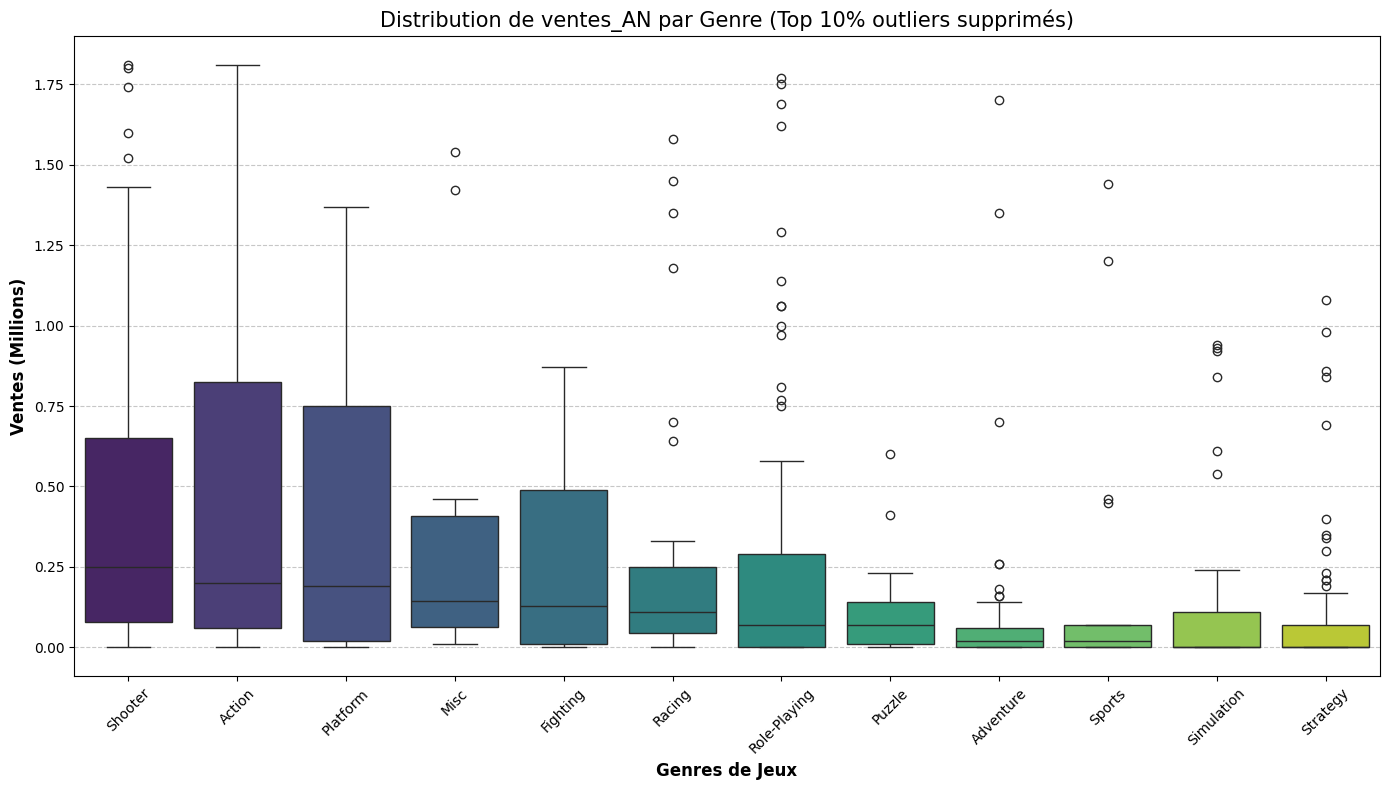

In [41]:
plot_boxplot_genres('ventes_AN', "Genres de Jeux", "Ventes (Millions)")

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


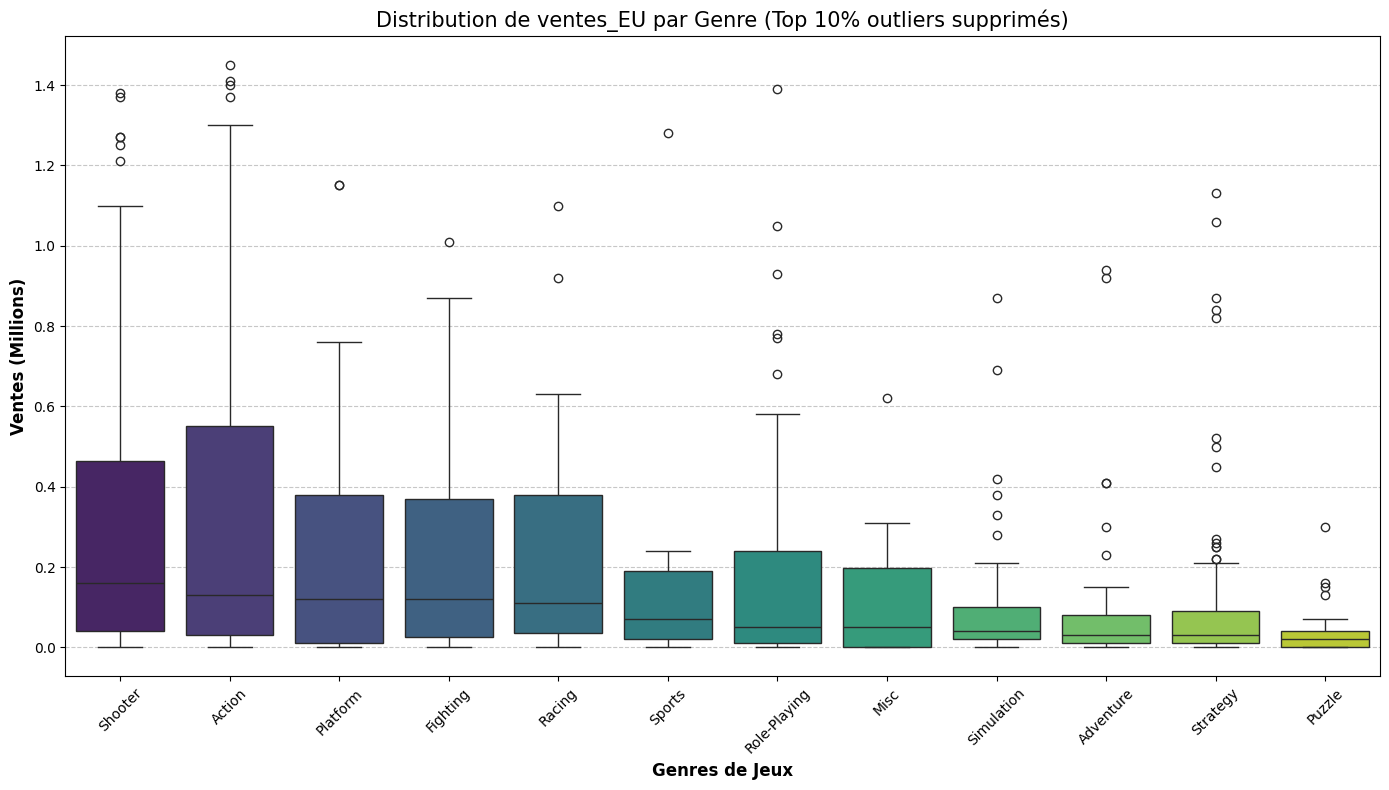

In [42]:
plot_boxplot_genres('ventes_EU', "Genres de Jeux", "Ventes (Millions)")

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


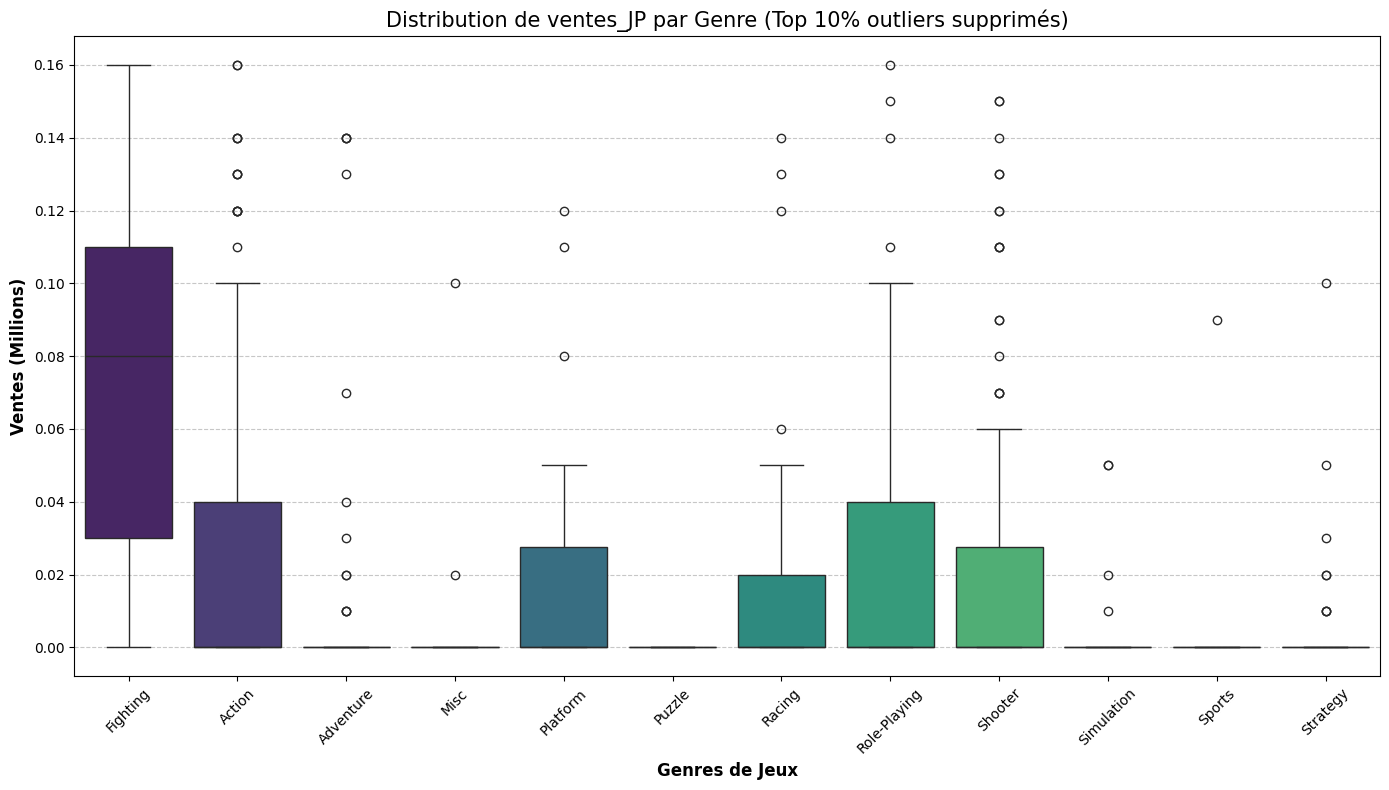

In [43]:
plot_boxplot_genres('ventes_JP', "Genres de Jeux", "Ventes (Millions)")

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


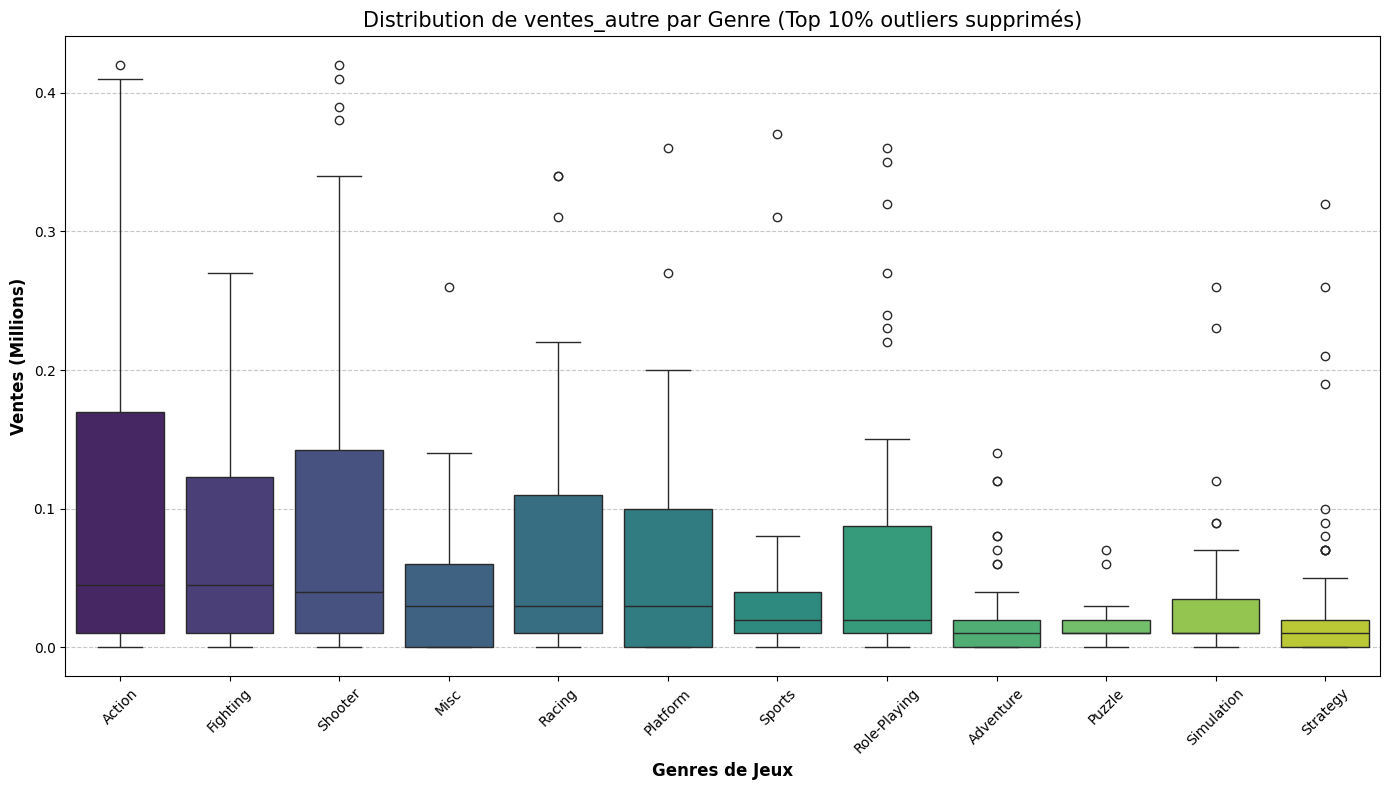

In [44]:
plot_boxplot_genres('ventes_autre', "Genres de Jeux", "Ventes (Millions)")

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


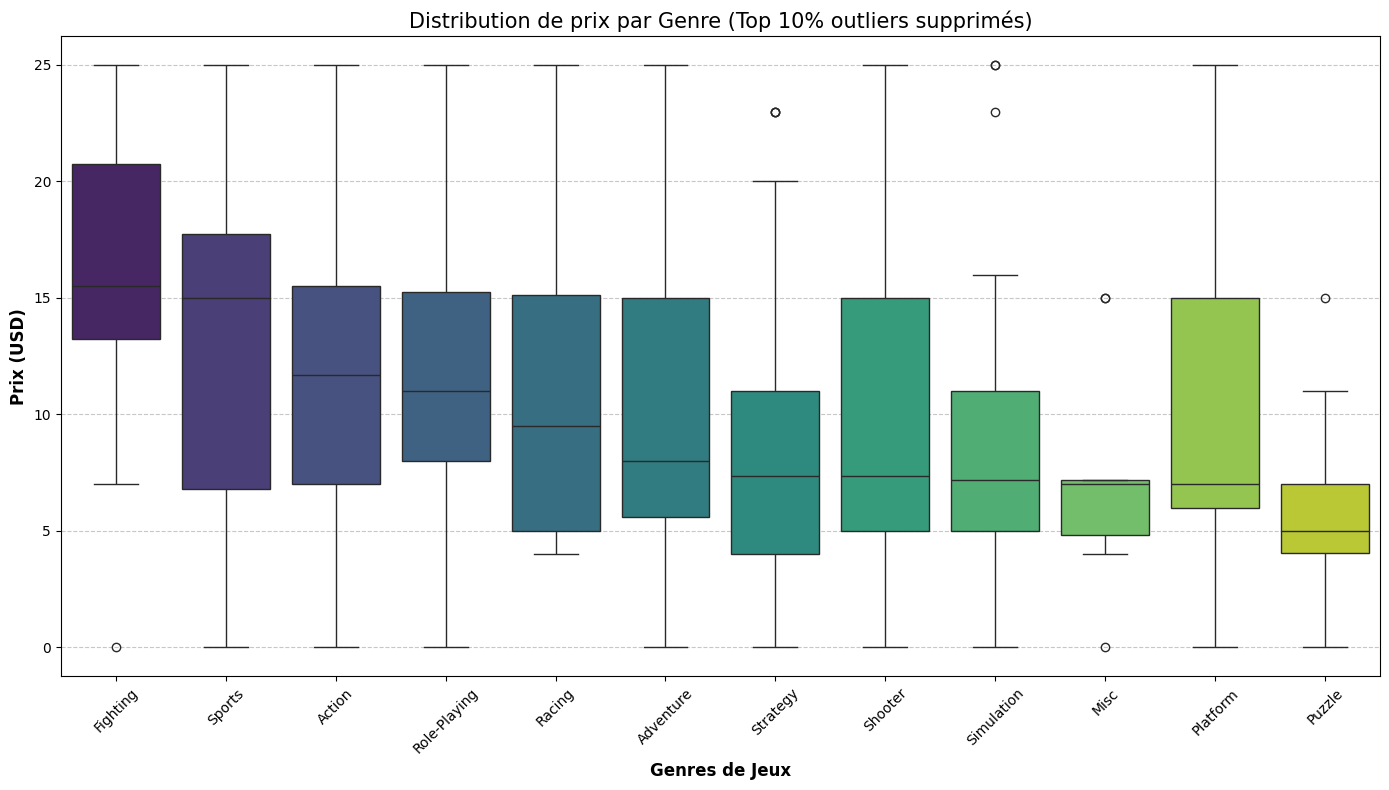

In [49]:
plot_boxplot_genres('prix', "Genres de Jeux", "Prix (USD)")

In [ ]:
def plot_boxplot_editeur_top30(numeric_col, label_x="Ventes", label_y="Éditeur"):
    connect = getBDD()
    if not connect: return

    sql = f"SELECT editeur.editeur, jeux.{numeric_col} FROM jeux JOIN editeur ON jeux.id_jeu = editeur.id_jeu"
    df = pd.read_sql(sql, connect)
    connect.close()

    df[numeric_col] = df[numeric_col].astype(str).str.replace(',', '.')
    df[numeric_col] = pd.to_numeric(df[numeric_col], errors='coerce')

    df['editeur'] = df['editeur'].astype(str).str.strip()
    
    df['editeur'] = df['editeur'].str.split(';')
    df = df.explode('editeur')

    df['editeur'] = df['editeur'].str.strip()
    df['editeur'] = df['editeur'].str.title() 

    df = df[df['editeur'] != '']
    df = df[df['editeur'].str.lower() != 'nan']
    df = df.dropna(subset=[numeric_col, 'editeur'])

    top_30= df.groupby('editeur')[numeric_col].mean().sort_values(ascending=False).head(30).index
    df_top30 = df[df['editeur'].isin(top_30)]

    plt.figure(figsize=(12, 10))
    sns.boxplot(data=df_top30, y='editeur', x=numeric_col, order=top_30, palette='viridis')

    plt.title(f'Top 30 Éditeurs par moyenne de {numeric_col}', fontsize=14)
    plt.xlabel(label_x, fontsize=12)
    plt.ylabel(label_y, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# --- RUN IT ---
# plot_boxplot_editeur_top20('ventes_global', label_x="Ventes Globales (Millions)", label_y="Éditeurs")

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\74713503.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\74713503.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


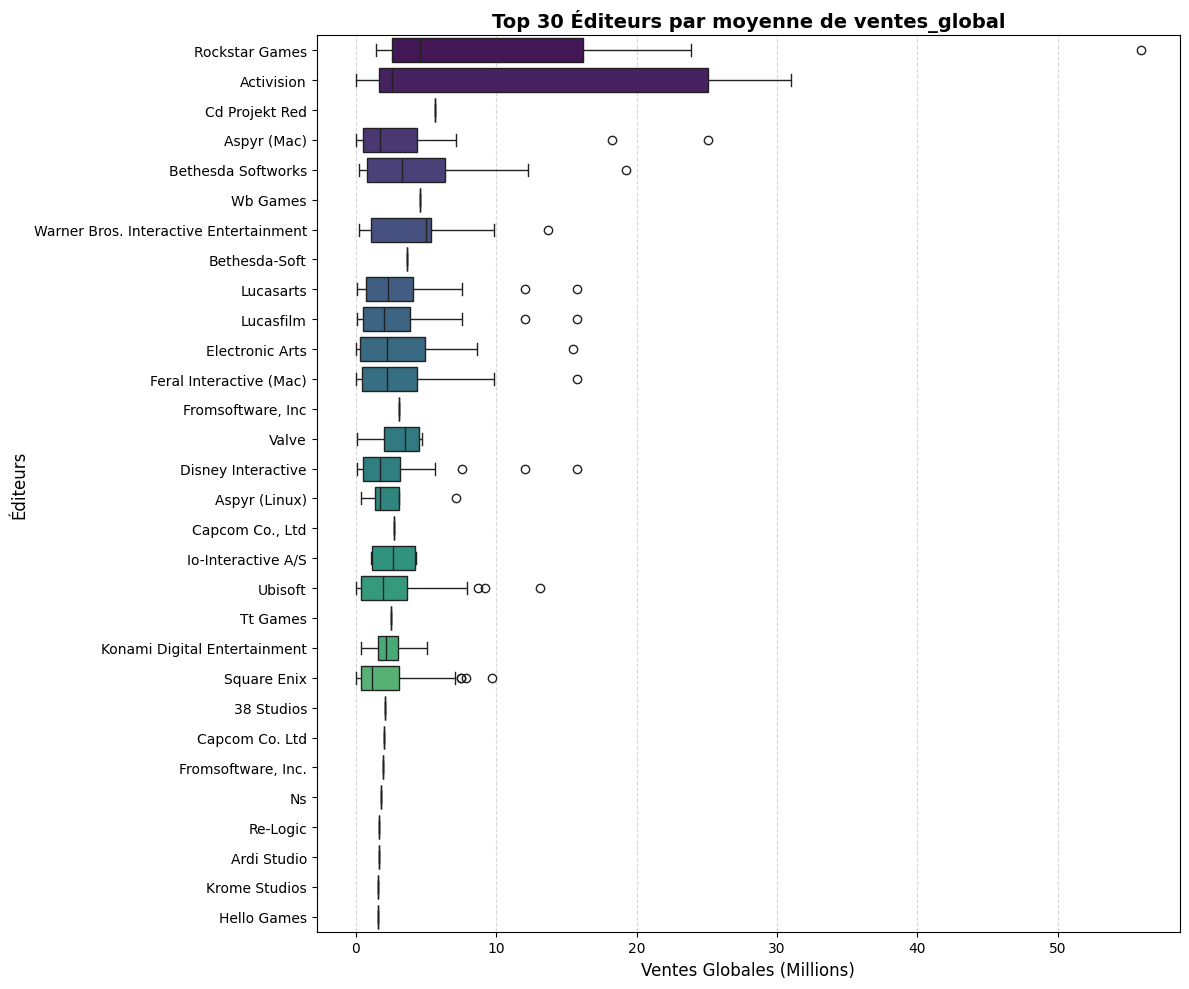

In [65]:
plot_boxplot_editeur_top20('ventes_global', label_x="Ventes Globales (Millions)", label_y="Éditeurs")